# Comparison Solvers with Regular Grid
This notebook builds the same regular-grid experiment under one shared set of soil and rainfall parameters.
The goal is to compare two Richards-equation solvers on the same domain discretization: the prism-based finite-volume solver and the 3D Modified Picard solver.

## Import Required Libraries

In [19]:
from solver.richards_model import RichardsSolver
from solver.richards_3d_modified_picard import Richards3DModifiedPicard
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

## Define Soil Parameters

All soil-hydraulic parameters are stored once and reused for both grids.

In [20]:
shared_soil = {
    'alpha': 0.067 * 100,
    'n_vg': 2.0,
    'theta_r': 0.075,
    'theta_s': 0.287,
    'Ks': 100 / 100 / 3600,
    'S_s': 1e-10,
}

shared_domain = {
    'n_layers': 5,
    'dz': np.full(5, 0.04),
    'base_elevation': 10.1,
    'dx': 0.04,
}

shared_soil

{'alpha': 6.7,
 'n_vg': 2.0,
 'theta_r': 0.075,
 'theta_s': 0.287,
 'Ks': 0.0002777777777777778,
 'S_s': 1e-10}

## Define Rainfall Input

The same rainfall intensity and time stepping are used in both experiments. Rain is applied to the same four top-surface regular-grid cells for both solvers.

In [21]:
shared_time = {
    'dt': 864,
    'steps': 150,
}

shared_rainfall = {
    'intensity': 0.1 / 100 / 86400,
    'series': np.full(shared_time['steps'], 0.1 / 100 / 86400),
    'regular_prisms': [10, 4, 5, 11],
    'unstructured_prisms': [1],
}

shared_rainfall

{'intensity': 1.1574074074074074e-08,
 'series': array([1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.15740741e-08, 1.15740741e-08, 1.15740741e-08, 1.15740741e-08,
        1.157407

## Define Regular Grid

In [22]:
def generate_regular_grid(rows=7, cols=6, dx=0.04):
    adj_prisms = {}
    A_ij = {}
    W_ij = np.zeros((rows * cols, rows * cols))
    L_ij = np.zeros((rows * cols, rows * cols))

    for r in range(rows):
        for c in range(cols):
            i = r * cols + c
            adj_prisms[i] = []
            A_ij[i] = dx * dx

            neighbors = [(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)]
            for nr, nc in neighbors:
                if 0 <= nr < rows and 0 <= nc < cols:
                    j = nr * cols + nc
                    adj_prisms[i].append(j)
                    W_ij[i, j] = dx
                    L_ij[i, j] = dx

    W_dict = {i: list(W_ij[i]) for i in range(rows * cols)}
    L_dict = {i: list(L_ij[i]) for i in range(rows * cols)}
    return adj_prisms, A_ij, W_dict, L_dict

rows_reg, cols_reg = 7, 6
adj_reg, areas_reg, widths_reg, lengths_reg = generate_regular_grid(rows_reg, cols_reg, dx=shared_domain['dx'])
n_prisms_reg = rows_reg * cols_reg

## Visualize Grid Comparison

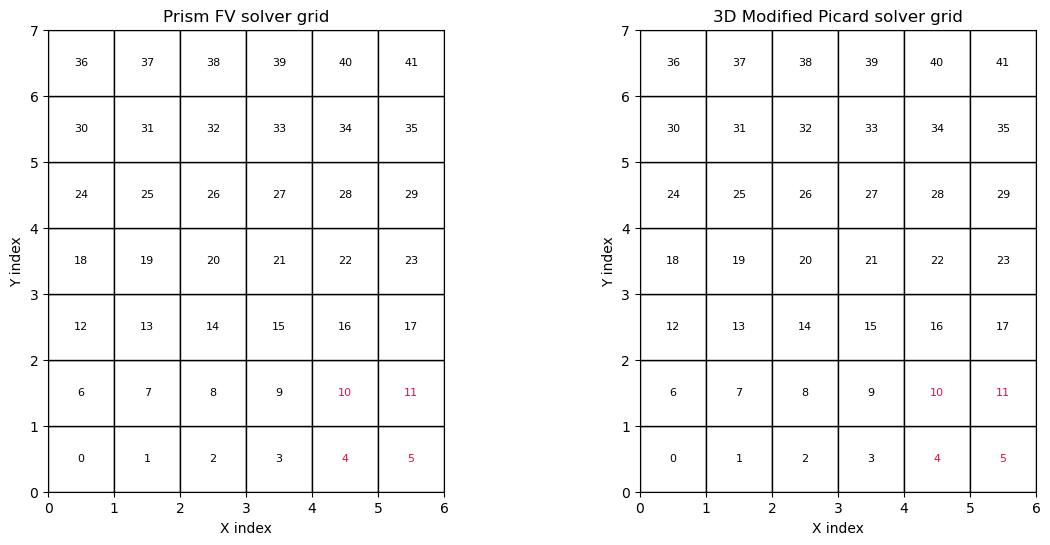

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, title in [
    (ax1, 'Prism FV solver grid'),
    (ax2, '3D Modified Picard solver grid'),
]:
    regular_patches = []
    for r in range(rows_reg):
        for c in range(cols_reg):
            prism = r * cols_reg + c
            square = [(c, r), (c + 1, r), (c + 1, r + 1), (c, r + 1)]
            regular_patches.append(MplPolygon(square, closed=True))
            color = 'crimson' if prism in shared_rainfall['regular_prisms'] else 'black'
            ax.text(c + 0.5, r + 0.5, str(prism), ha='center', va='center', fontsize=8, color=color)

    pc_reg = PatchCollection(regular_patches, facecolor='white', edgecolor='black', linewidth=1)
    ax.add_collection(pc_reg)
    ax.set_xlim(0, cols_reg)
    ax.set_ylim(0, rows_reg)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('X index')
    ax.set_ylabel('Y index')

plt.show()

# Build Solvers with Regular Grid

In [24]:
# Regular grid solver with Prisms 
reg_grid_solver = RichardsSolver(
    alpha=shared_soil['alpha'],
    n_vg=shared_soil['n_vg'],
    theta_r=np.full((n_prisms_reg, shared_domain['n_layers']), shared_soil['theta_r']),
    theta_s=np.full((n_prisms_reg, shared_domain['n_layers']), shared_soil['theta_s']),
    Ks=np.full((n_prisms_reg, shared_domain['n_layers']), shared_soil['Ks']),
    S_s=shared_soil['S_s'],
    dz=shared_domain['dz'],
    base_elevations=np.full(n_prisms_reg, shared_domain['base_elevation']),
    rainfall_intensity=shared_rainfall['intensity'],
    rainfall_prisms=shared_rainfall['regular_prisms'],
    adj_prisms=adj_reg,
    A_ij=areas_reg,
    W_ij=widths_reg,
    L_ij=lengths_reg,
)

print(f'Regular grid prisms: {n_prisms_reg}')

Regular grid prisms: 42


In [25]:
# Regular grid solver with 3D discretization and Modified Picard
rows, cols = 7, 6
reg_grid_solver_3d = Richards3DModifiedPicard(
    nx=cols,
    ny=rows,
    nz=shared_domain['n_layers'],
    dx=shared_domain['dx'],
    dy=shared_domain['dx'],
    dz=0.04, #needs to be modified to allow for variable layer thicknesses.
    z_base=shared_domain['base_elevation'],
    alpha=shared_soil['alpha'],
    n_vg=shared_soil['n_vg'],
    theta_r=shared_soil['theta_r'],
    theta_s=shared_soil['theta_s'],
    Ks=shared_soil['Ks'],
    S_s=shared_soil['S_s'],
    )

# Rain applied only on these top-surface cell IDs
rain_ids = [10, 4, 5, 11]

print(f"Grid: nx={reg_grid_solver_3d.nx}, ny={reg_grid_solver_3d.ny}, nz={reg_grid_solver_3d.nz}, total_cells={reg_grid_solver_3d.n}")
print(f"Bottom elevation reference z_base={np.unique(reg_grid_solver_3d.z_base)} m")

Grid: nx=6, ny=7, nz=5, total_cells=210
Bottom elevation reference z_base=[10.1] m


In [26]:
# Build a top-flux field (ny x nx), matching rain_ids from the prism indexing i = row*cols + col
top_flux = np.zeros((rows, cols), dtype=float)
for pid in rain_ids:
    r = pid // cols
    c = pid % cols
    top_flux[r, c] = shared_rainfall['intensity']

## Compare Integrated Metrics

In [27]:
solver_a_label = 'Prism FV'
solver_b_label = '3D Modified Picard'
solver_a = reg_grid_solver
solver_b = reg_grid_solver_3d

# Enforce identical nonlinear controls for both solvers.
shared_nonlinear = {
    'max_iter': 50,
    'tol': 1e-6,
}


def initial_head_state(solver, h0_value=-10.0):
    return np.full(solver.total_cells, h0_value, dtype=float)


def solve_step_with_shared_forcing(solver, h, dt):
    if isinstance(solver, Richards3DModifiedPicard):
        return solver.solve_step(
            h,
            dt,
            top_flux=top_flux,
            max_iter=shared_nonlinear['max_iter'],
            tol=shared_nonlinear['tol'],
        )
    return solver.solve_step(
        h,
        dt,
        max_iter=shared_nonlinear['max_iter'],
        tol=shared_nonlinear['tol'],
    )


def boundary_flux_with_shared_forcing(solver, h):
    if isinstance(solver, Richards3DModifiedPicard):
        return solver.get_boundary_flux_with_rain(h, top_flux=top_flux)
    return solver.get_boundary_flux_with_rain(h)


def get_cell_volumes(solver):
    if isinstance(solver, Richards3DModifiedPicard):
        return np.full(solver.total_cells, solver.cell_volume, dtype=float)

    volumes = np.zeros(solver.total_cells)
    for k in range(solver.n_layers):
        for i in range(solver.n_prisms):
            idx = k * solver.n_prisms + i
            volumes[idx] = solver.A_ij[i] * solver.dz[k]
    return volumes


def compute_vertical_net_flux(solver, h):
    if isinstance(solver, Richards3DModifiedPicard):
        h_3d = solver._unflatten(h)
        k_3d = solver.conductivity(h_3d)
        net = np.zeros_like(h_3d)

        for k in range(solver.nz):
            for j in range(solver.ny):
                for i in range(solver.nx):
                    z_i = solver.z_centers[k, j, i]
                    for kn in [k - 1, k + 1]:
                        if 0 <= kn < solver.nz:
                            k_face = solver._harmonic_mean(k_3d[k, j, i], k_3d[kn, j, i])
                            conductance = solver.cell_area * k_face / solver.dz_scalar
                            total_head_grad = (h_3d[kn, j, i] - h_3d[k, j, i]) + (solver.z_centers[kn, j, i] - z_i)
                            net[k, j, i] += conductance * total_head_grad
        return net.reshape(-1)

    solver.Z = np.array([solver.get_z_centers(b, solver.dz) for b in solver.base_elevations])
    net = np.zeros(solver.total_cells)
    for k in range(solver.n_layers):
        for i in range(solver.n_prisms):
            idx_i = k * solver.n_prisms + i
            for direction in [-1, 1]:
                adj_k = k + direction
                if 0 <= adj_k < solver.n_layers:
                    idx_j = adj_k * solver.n_prisms + i
                    k_face = 2.0 / (1.0 / solver.get_K(h[idx_i], k, i) + 1.0 / solver.get_K(h[idx_j], adj_k, i))
                    dz_dist = abs(solver.Z[i, adj_k] - solver.Z[i, k])
                    conductance = solver.A_ij[i] * k_face / dz_dist
                    total_head_grad = solver.get_total_head_gradient(h[idx_i], solver.Z[i, k], h[idx_j], solver.Z[i, adj_k])
                    net[idx_i] += conductance * total_head_grad
    return net


def run_experiment_metrics(solver, dt, steps, h0_value=-10.0):
    h = initial_head_state(solver, h0_value=h0_value)
    s0 = solver.calculate_storage(h)
    cumulative_inflow = 0.0
    cumulative_lateral_exchange = 0.0

    for _ in range(steps):
        h = solve_step_with_shared_forcing(solver, h, dt)
        q_in = boundary_flux_with_shared_forcing(solver, h)
        cumulative_inflow += q_in * dt
        q_lat = solver.get_total_lateral_exchange(h)
        cumulative_lateral_exchange += q_lat * dt

    s_end = solver.calculate_storage(h)
    storage_change = s_end - s0
    mass_error = storage_change - cumulative_inflow
    rel_mass_error_pct = 100.0 * mass_error / (abs(cumulative_inflow) + 1e-30)

    return {
        'storage_initial_m3': s0,
        'storage_final_m3': s_end,
        'storage_change_m3': storage_change,
        'cumulative_inflow_m3': cumulative_inflow,
        'mass_error_m3': mass_error,
        'rel_mass_error_pct': rel_mass_error_pct,
        'cumulative_lateral_exchange_m3': cumulative_lateral_exchange,
    }


def relative_difference_pct(a, b):
    denom = max(abs(a), abs(b), 1e-30)
    return 100.0 * abs(a - b) / denom


solver_a_metrics = run_experiment_metrics(solver_a, shared_time['dt'], shared_time['steps'])
solver_b_metrics = run_experiment_metrics(solver_b, shared_time['dt'], shared_time['steps'])

metric_keys = [
    'storage_initial_m3',
    'storage_final_m3',
    'storage_change_m3',
    'cumulative_inflow_m3',
    'mass_error_m3',
    'rel_mass_error_pct',
    'cumulative_lateral_exchange_m3',
]

print(
    f"Comparison settings: dt={shared_time['dt']} s, steps={shared_time['steps']}, "
    f"max_iter={shared_nonlinear['max_iter']}, tol={shared_nonlinear['tol']:.1e}"
)
print('=' * 116)
print(f"{'Metric':<34} | {solver_a_label:>20} | {solver_b_label:>20} | {'RelDiff %':>12}")
print('-' * 116)
for key in metric_keys:
    a_val = solver_a_metrics[key]
    b_val = solver_b_metrics[key]
    rel_diff = relative_difference_pct(a_val, b_val)
    print(f"{key:<34} | {a_val:>20.6e} | {b_val:>20.6e} | {rel_diff:>12.4f}")
print('=' * 116)

Comparison settings: dt=864 s, steps=150, max_iter=50, tol=1.0e-06
Metric                             |             Prism FV |   3D Modified Picard |    RelDiff %
--------------------------------------------------------------------------------------------------------------------
storage_initial_m3                 |         1.050522e-03 |         1.050522e-03 |       0.0000
storage_final_m3                   |         1.060122e-03 |         1.060122e-03 |       0.0000
storage_change_m3                  |         9.600000e-06 |         9.600000e-06 |       0.0000
cumulative_inflow_m3               |         9.600000e-06 |         9.600000e-06 |       0.0000
mass_error_m3                      |         5.241440e-18 |         6.759323e-18 |      22.4561
rel_mass_error_pct                 |         5.459833e-11 |         7.040961e-11 |      22.4561
cumulative_lateral_exchange_m3     |         2.999323e-07 |         2.999323e-07 |       0.0000


## Compare Mass-Error Time Series

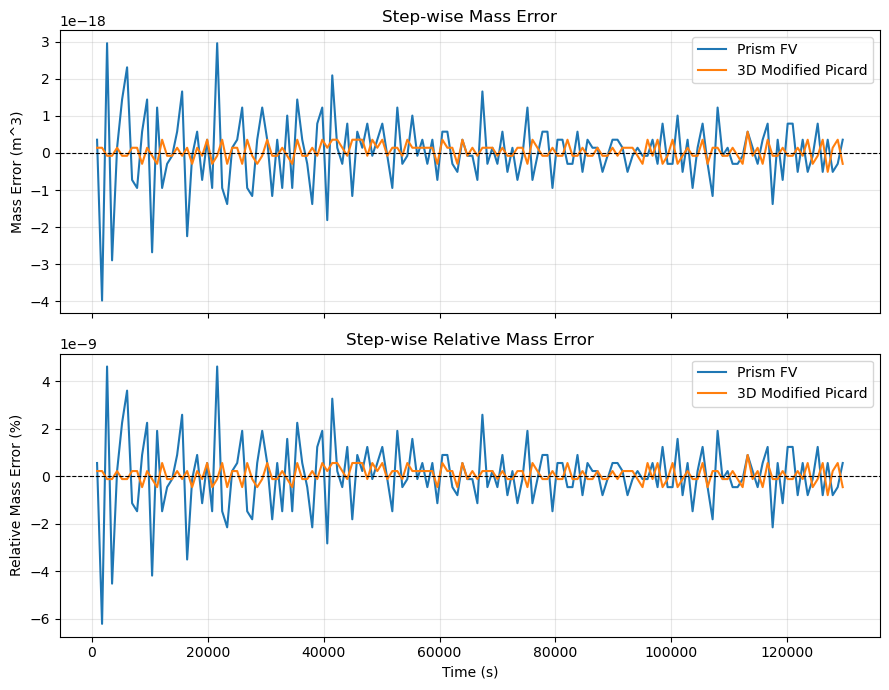

In [28]:
def mass_error_time_series(solver, dt, steps, h0_value=-10.0):
    h = initial_head_state(solver, h0_value=h0_value)
    times = []
    step_mass_error = []
    step_rel_mass_error_pct = []

    for t in range(steps):
        s_old = solver.calculate_storage(h)
        h_next = solve_step_with_shared_forcing(solver, h, dt)
        s_new = solver.calculate_storage(h_next)
        q_in = boundary_flux_with_shared_forcing(solver, h_next)

        expected_change = q_in * dt
        actual_change = s_new - s_old
        err = actual_change - expected_change
        rel_err = 100.0 * err / (abs(expected_change) + 1e-30)

        times.append((t + 1) * dt)
        step_mass_error.append(err)
        step_rel_mass_error_pct.append(rel_err)
        h = h_next

    return np.array(times), np.array(step_mass_error), np.array(step_rel_mass_error_pct)


ta, err_a, rel_a = mass_error_time_series(solver_a, shared_time['dt'], shared_time['steps'])
tb, err_b, rel_b = mass_error_time_series(solver_b, shared_time['dt'], shared_time['steps'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax1.plot(ta, err_a, label=solver_a_label, color='tab:blue')
ax1.plot(tb, err_b, label=solver_b_label, color='tab:orange')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_ylabel('Mass Error (m^3)')
ax1.set_title('Step-wise Mass Error')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(ta, rel_a, label=solver_a_label, color='tab:blue')
ax2.plot(tb, rel_b, label=solver_b_label, color='tab:orange')
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Relative Mass Error (%)')
ax2.set_title('Step-wise Relative Mass Error')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## Full Per-Step Budget Diagnostics

In [29]:
def run_budget_diagnostics(solver, dt, steps, h0_value=-10.0):
    h = initial_head_state(solver, h0_value=h0_value)

    times = np.zeros(steps)
    dS = np.zeros(steps)
    q_rain_vol = np.zeros(steps)
    lat_exchange = np.zeros(steps)
    vert_net_in = np.zeros(steps)
    mass_error = np.zeros(steps)
    cum_error = np.zeros(steps)

    cumulative = 0.0
    for t in range(steps):
        s_old = solver.calculate_storage(h)
        h_next = solve_step_with_shared_forcing(solver, h, dt)
        s_new = solver.calculate_storage(h_next)

        q_in = boundary_flux_with_shared_forcing(solver, h_next)
        q_lat = solver.get_total_lateral_exchange(h_next)
        q_vert = compute_vertical_net_flux(solver, h_next).sum()

        delta_s = s_new - s_old
        expected = q_in * dt
        err = delta_s - expected
        cumulative += err

        times[t] = (t + 1) * dt
        dS[t] = delta_s
        q_rain_vol[t] = expected
        lat_exchange[t] = q_lat * dt
        vert_net_in[t] = q_vert * dt
        mass_error[t] = err
        cum_error[t] = cumulative
        h = h_next

    return {
        'times': times,
        'dS': dS,
        'q_rain_vol': q_rain_vol,
        'lat_exchange': lat_exchange,
        'vert_net_in': vert_net_in,
        'mass_error': mass_error,
        'cum_error': cum_error,
    }

bd_a = run_budget_diagnostics(solver_a, shared_time['dt'], shared_time['steps'])
bd_b = run_budget_diagnostics(solver_b, shared_time['dt'], shared_time['steps'])

cols_def = [
    ('Time(s)', 'times', 'a'),
    ('dS_A', 'dS', 'a'),
    ('Qrain_A', 'q_rain_vol', 'a'),
    ('Qlat_A', 'lat_exchange', 'a'),
    ('Qvert_A', 'vert_net_in', 'a'),
    ('Err_A', 'mass_error', 'a'),
    ('CumErr_A', 'cum_error', 'a'),
    ('dS_B', 'dS', 'b'),
    ('Qrain_B', 'q_rain_vol', 'b'),
    ('Qlat_B', 'lat_exchange', 'b'),
    ('Qvert_B', 'vert_net_in', 'b'),
    ('Err_B', 'mass_error', 'b'),
    ('CumErr_B', 'cum_error', 'b'),
]

width = 14
print('-' * (width * len(cols_def) + len(cols_def) - 1))
print(' | '.join(f"{label:>{width}}" for label, _, _ in cols_def))
print('-' * (width * len(cols_def) + len(cols_def) - 1))
for t in range(shared_time['steps']):
    values = []
    for _, key, which in cols_def:
        src = bd_a if which == 'a' else bd_b
        values.append(src[key][t])
    print(' | '.join(f"{value:>{width}.4e}" for value in values))
print('-' * (width * len(cols_def) + len(cols_def) - 1))

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
       Time(s) |           dS_A |        Qrain_A |         Qlat_A |        Qvert_A |          Err_A |       CumErr_A |           dS_B |        Qrain_B |         Qlat_B |        Qvert_B |          Err_B |       CumErr_B
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    8.6400e+02 |     6.4000e-08 |     6.4000e-08 |     4.9833e-11 |    -2.7263e-27 |     3.5718e-19 |     3.5718e-19 |     6.4000e-08 |     6.4000e-08 |     4.9833e-11 |    -8.1789e-27 |     1.4034e-19 |     1.4034e-19
    1.7280e+03 |     6.4000e-08 |     6.4000e-08 |     1.0473e-10 |    -5.4526e-27 |    -3.9796e-18 |    -3.6224e-18 |     6.4000e-08 |     6.4000e-08 |     1.0473e-10 |   

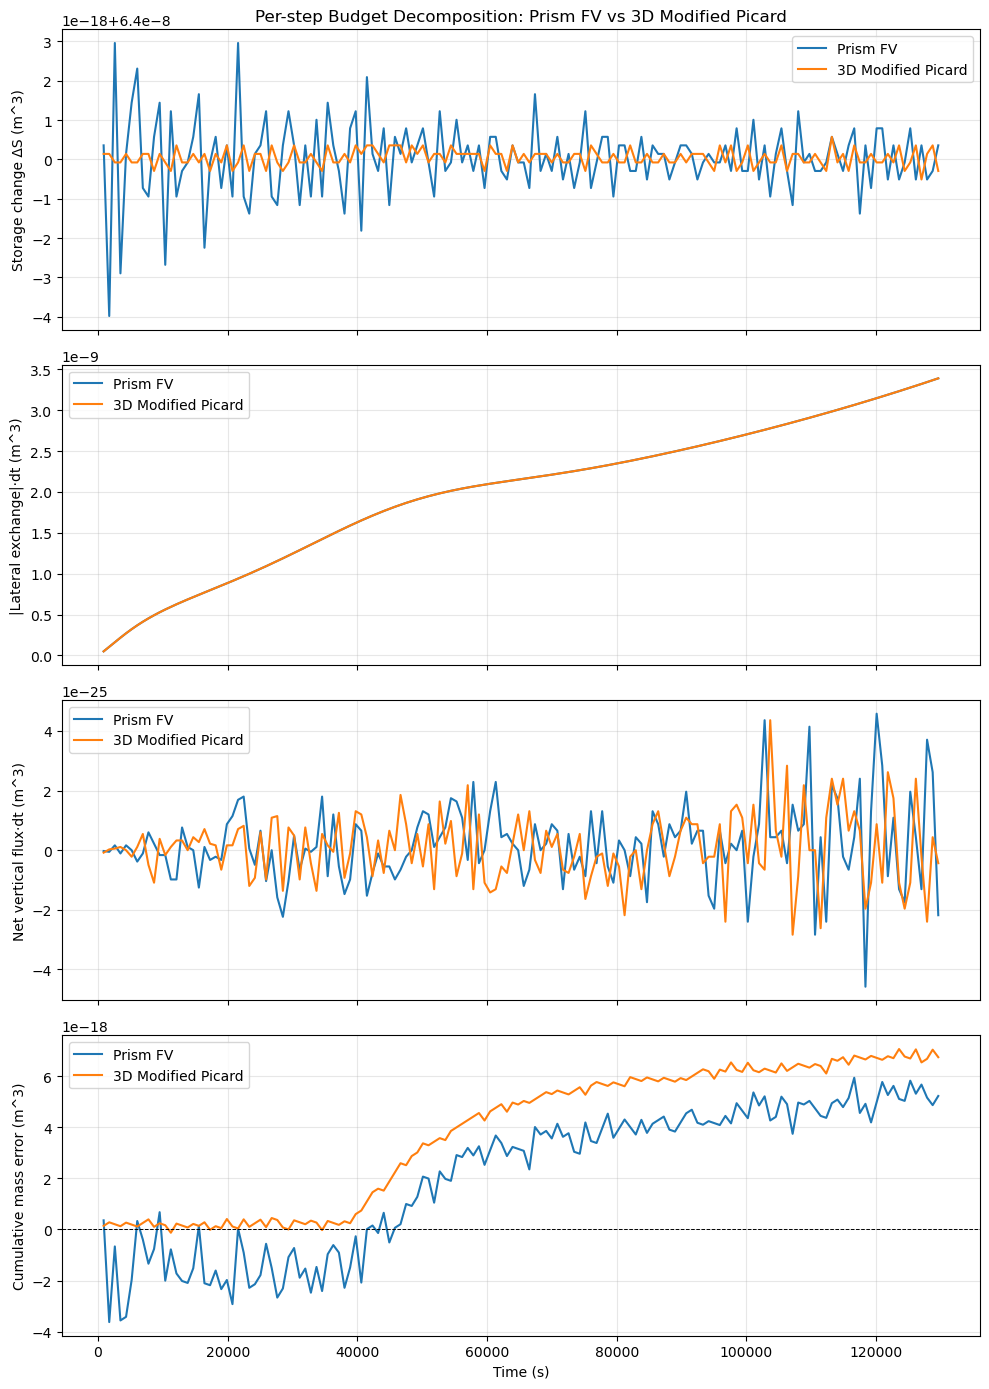

In [30]:
fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)
plot_config = [
    ('Storage change ΔS (m^3)', 'dS', False),
    ('|Lateral exchange|·dt (m^3)', 'lat_exchange', False),
    ('Net vertical flux·dt (m^3)', 'vert_net_in', False),
    ('Cumulative mass error (m^3)', 'cum_error', True),
]

for ax, (ylabel, key, add_zero) in zip(axes, plot_config):
    ax.plot(bd_a['times'], bd_a[key], label=solver_a_label, color='tab:blue')
    ax.plot(bd_b['times'], bd_b[key], label=solver_b_label, color='tab:orange')
    if add_zero:
        ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_title('Per-step Budget Decomposition: Prism FV vs 3D Modified Picard')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## Δt Refinement Study

This section repeats the same experiment with progressively smaller time steps while keeping the total simulated time fixed. It helps separate time-integration error from geometry-dependent effects.

  dt (s) |    steps |           Prism FV | 3D Modified Picard
--------------------------------------------------------------------------------
     864 |      150 |       5.241440e-18 |       6.759323e-18
     432 |      300 |      -6.556035e-19 |       8.622795e-19
     216 |      600 |      -8.639736e-19 |       3.388132e-21
     108 |     1200 |      -1.568705e-18 |       3.828589e-19


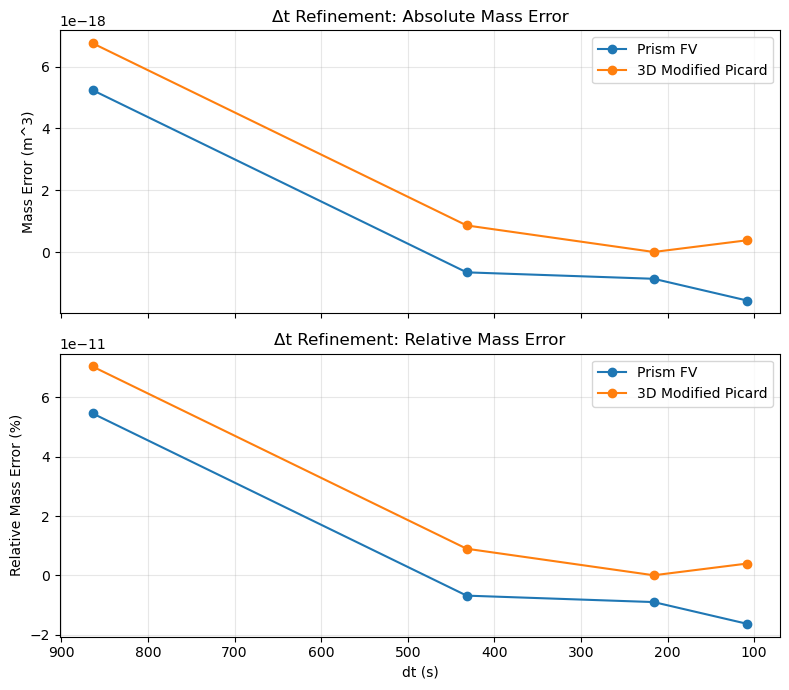

In [31]:
total_time = shared_time['dt'] * shared_time['steps']
dt_values = [864, 432, 216, 108]
refinement_results = []

for dt_value in dt_values:
    steps_value = total_time // dt_value
    if total_time % dt_value != 0:
        raise ValueError(f'dt={dt_value} does not divide total_time={total_time}')

    solver_a_metrics_dt = run_experiment_metrics(solver_a, dt_value, int(steps_value))
    solver_b_metrics_dt = run_experiment_metrics(solver_b, dt_value, int(steps_value))

    refinement_results.append({
        'dt': dt_value,
        'steps': int(steps_value),
        'solver_a_mass_error': solver_a_metrics_dt['mass_error_m3'],
        'solver_b_mass_error': solver_b_metrics_dt['mass_error_m3'],
        'solver_a_rel_mass_error_pct': solver_a_metrics_dt['rel_mass_error_pct'],
        'solver_b_rel_mass_error_pct': solver_b_metrics_dt['rel_mass_error_pct'],
        'solver_a_lateral_exchange': solver_a_metrics_dt['cumulative_lateral_exchange_m3'],
        'solver_b_lateral_exchange': solver_b_metrics_dt['cumulative_lateral_exchange_m3'],
    })

print(f"{'dt (s)':>8} | {'steps':>8} | {solver_a_label:>18} | {solver_b_label:>18}")
print('-' * 80)
for row in refinement_results:
    print(
        f"{row['dt']:>8d} | {row['steps']:>8d} | {row['solver_a_mass_error']:>18.6e} | {row['solver_b_mass_error']:>18.6e}"
    )

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
ax1.plot(dt_values, [row['solver_a_mass_error'] for row in refinement_results], marker='o', label=solver_a_label, color='tab:blue')
ax1.plot(dt_values, [row['solver_b_mass_error'] for row in refinement_results], marker='o', label=solver_b_label, color='tab:orange')
ax1.set_ylabel('Mass Error (m^3)')
ax1.set_title('Δt Refinement: Absolute Mass Error')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(dt_values, [row['solver_a_rel_mass_error_pct'] for row in refinement_results], marker='o', label=solver_a_label, color='tab:blue')
ax2.plot(dt_values, [row['solver_b_rel_mass_error_pct'] for row in refinement_results], marker='o', label=solver_b_label, color='tab:orange')
ax2.set_xlabel('dt (s)')
ax2.set_ylabel('Relative Mass Error (%)')
ax2.set_title('Δt Refinement: Relative Mass Error')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

## No-Lateral-Flow Control Case

This control removes all horizontal conductance by setting every lateral face width to zero. The result isolates purely vertical infiltration and storage dynamics on both grids.

Metric                             |      Prism FV full |    Prism FV no-lat | 3D Modified Picard full | 3D Modified Picard no-lat
----------------------------------------------------------------------------------------------------------------------------------
storage_initial_m3                 |       1.050522e-03 |       1.050522e-03 |           1.050522e-03 |           1.050522e-03
storage_final_m3                   |       1.060122e-03 |       1.060122e-03 |           1.060122e-03 |           1.060122e-03
storage_change_m3                  |       9.600000e-06 |       9.600000e-06 |           9.600000e-06 |           9.600000e-06
cumulative_inflow_m3               |       9.600000e-06 |       9.600000e-06 |           9.600000e-06 |           9.600000e-06
mass_error_m3                      |       5.241440e-18 |       5.024599e-18 |           6.759323e-18 |           2.856195e-18
rel_mass_error_pct                 |       5.459833e-11 |       5.233958e-11 |           7.040961e-11 |

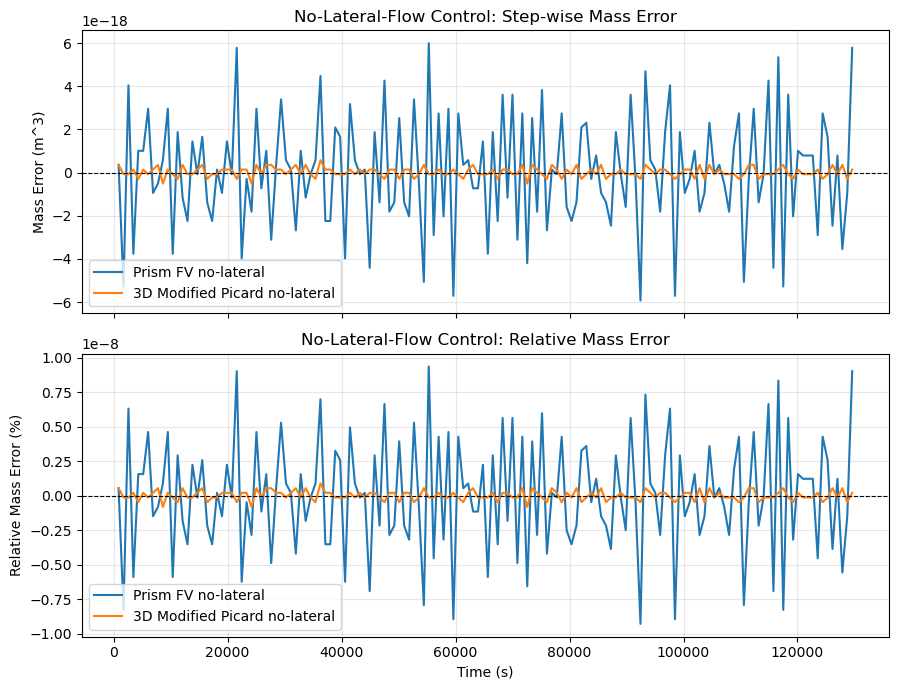

In [32]:
def zero_lateral_widths(widths_dict):
    return {prism: [0.0 for _ in row] for prism, row in widths_dict.items()}


solver_a_vertical_only = RichardsSolver(
    alpha=shared_soil['alpha'],
    n_vg=shared_soil['n_vg'],
    theta_r=np.full((n_prisms_reg, shared_domain['n_layers']), shared_soil['theta_r']),
    theta_s=np.full((n_prisms_reg, shared_domain['n_layers']), shared_soil['theta_s']),
    Ks=np.full((n_prisms_reg, shared_domain['n_layers']), shared_soil['Ks']),
    S_s=shared_soil['S_s'],
    dz=shared_domain['dz'],
    base_elevations=np.full(n_prisms_reg, shared_domain['base_elevation']),
    rainfall_intensity=shared_rainfall['intensity'],
    rainfall_prisms=shared_rainfall['regular_prisms'],
    adj_prisms=adj_reg,
    A_ij=areas_reg,
    W_ij=zero_lateral_widths(widths_reg),
    L_ij=lengths_reg,
)

solver_b_vertical_only = Richards3DModifiedPicard(
    nx=cols_reg,
    ny=rows_reg,
    nz=shared_domain['n_layers'],
    dx=shared_domain['dx'],
    dy=shared_domain['dx'],
    dz=shared_domain['dz'][0],
    z_base=shared_domain['base_elevation'],
    alpha=shared_soil['alpha'],
    n_vg=shared_soil['n_vg'],
    theta_r=shared_soil['theta_r'],
    theta_s=shared_soil['theta_s'],
    Ks=shared_soil['Ks'],
    S_s=shared_soil['S_s'],
    lateral_flow_scale=0.0,
)

solver_a_metrics_vertical_only = run_experiment_metrics(solver_a_vertical_only, shared_time['dt'], shared_time['steps'])
solver_b_metrics_vertical_only = run_experiment_metrics(solver_b_vertical_only, shared_time['dt'], shared_time['steps'])

print(f"{'Metric':<34} | {solver_a_label + ' full':>18} | {solver_a_label + ' no-lat':>18} | {solver_b_label + ' full':>22} | {solver_b_label + ' no-lat':>22}")
print('-' * 130)
for key in metric_keys:
    print(
        f"{key:<34} | {solver_a_metrics[key]:>18.6e} | {solver_a_metrics_vertical_only[key]:>18.6e} | "
        f"{solver_b_metrics[key]:>22.6e} | {solver_b_metrics_vertical_only[key]:>22.6e}"
    )

ta_v, err_a_v, rel_a_v = mass_error_time_series(solver_a_vertical_only, shared_time['dt'], shared_time['steps'])
tb_v, err_b_v, rel_b_v = mass_error_time_series(solver_b_vertical_only, shared_time['dt'], shared_time['steps'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax1.plot(ta_v, err_a_v, label=f'{solver_a_label} no-lateral', color='tab:blue')
ax1.plot(tb_v, err_b_v, label=f'{solver_b_label} no-lateral', color='tab:orange')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_ylabel('Mass Error (m^3)')
ax1.set_title('No-Lateral-Flow Control: Step-wise Mass Error')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(ta_v, rel_a_v, label=f'{solver_a_label} no-lateral', color='tab:blue')
ax2.plot(tb_v, rel_b_v, label=f'{solver_b_label} no-lateral', color='tab:orange')
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Relative Mass Error (%)')
ax2.set_title('No-Lateral-Flow Control: Relative Mass Error')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## Lateral-Only Diagnostic by Depth

This section isolates horizontal exchange and compares the cumulative lateral exchange in each vertical layer for the full-flow cases.

   Layer |   Depth center (m) |                 Prism FV |       3D Modified Picard
----------------------------------------------------------------------------------------
       0 |       2.000000e-02 |             1.252936e-13 |             1.252936e-13
       1 |       6.000000e-02 |             6.261384e-12 |             6.261384e-12
       2 |       1.000000e-01 |             2.658255e-10 |             2.658255e-10
       3 |       1.400000e-01 |             9.095309e-09 |             9.095309e-09
       4 |       1.800000e-01 |             2.905647e-07 |             2.905647e-07


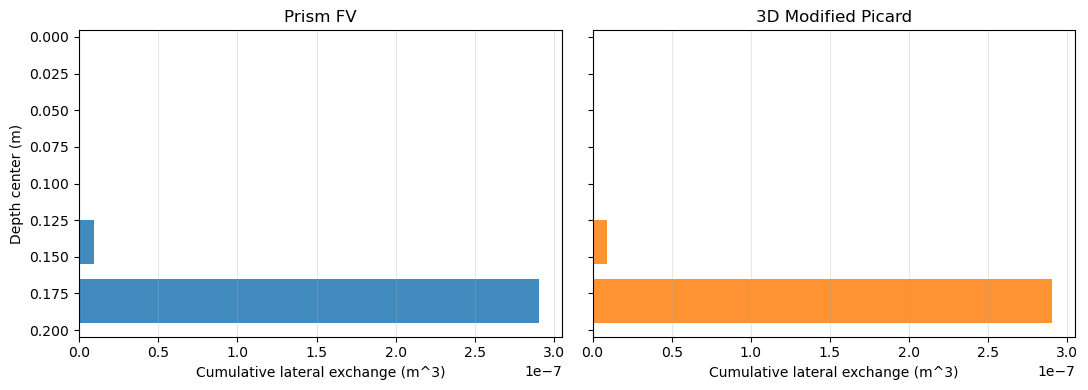

In [33]:
def per_layer_lateral_exchange_profile(solver, dt, steps, h0_value=-10.0):
    h = initial_head_state(solver, h0_value=h0_value)
    cumulative_by_layer = np.zeros(solver.n_layers)

    for _ in range(steps):
        h = solve_step_with_shared_forcing(solver, h, dt)
        for layer in range(solver.n_layers):
            layer_fluxes = solver.get_lateral_fluxes(h, layer=layer)
            cumulative_by_layer[layer] += sum(abs(q) for q in layer_fluxes.values()) * dt

    return cumulative_by_layer


lat_profile_a = per_layer_lateral_exchange_profile(solver_a, shared_time['dt'], shared_time['steps'])
lat_profile_b = per_layer_lateral_exchange_profile(solver_b, shared_time['dt'], shared_time['steps'])
layer_centers = np.cumsum(shared_domain['dz']) - 0.5 * shared_domain['dz']

print(f"{'Layer':>8} | {'Depth center (m)':>18} | {solver_a_label:>24} | {solver_b_label:>24}")
print('-' * 88)
for layer in range(shared_domain['n_layers']):
    print(
        f"{layer:>8d} | {layer_centers[layer]:>18.6e} | {lat_profile_a[layer]:>24.6e} | {lat_profile_b[layer]:>24.6e}"
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
ax1.barh(layer_centers, lat_profile_a, height=0.03, color='tab:blue', alpha=0.85)
ax1.invert_yaxis()
ax1.set_xlabel('Cumulative lateral exchange (m^3)')
ax1.set_ylabel('Depth center (m)')
ax1.set_title(solver_a_label)
ax1.grid(True, axis='x', alpha=0.3)

ax2.barh(layer_centers, lat_profile_b, height=0.03, color='tab:orange', alpha=0.85)
ax2.set_xlabel('Cumulative lateral exchange (m^3)')
ax2.set_title(solver_b_label)
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Log-Log Convergence Rate for the Δt Study

This section plots mass-balance error against time step on log-log axes and estimates the local slope between successive refinements.

Refinement pair    |     Prism FV slope | 3D Modified Picard slope
------------------------------------------------------------------------
864->432           |           2.999068 |                 2.970651
432->216           |          -0.398164 |                 7.991522
216->108           |          -0.860515 |                -6.820179


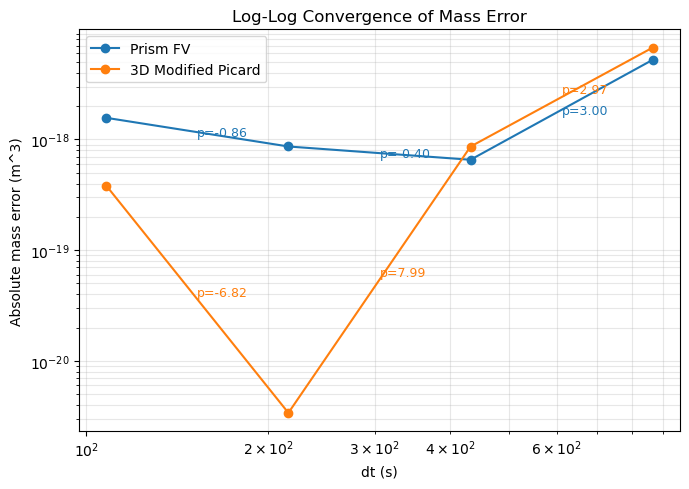

In [34]:
dt_array = np.array([row['dt'] for row in refinement_results], dtype=float)
solver_a_err_array = np.abs(np.array([row['solver_a_mass_error'] for row in refinement_results], dtype=float))
solver_b_err_array = np.abs(np.array([row['solver_b_mass_error'] for row in refinement_results], dtype=float))

solver_a_orders = np.log(solver_a_err_array[:-1] / solver_a_err_array[1:]) / np.log(dt_array[:-1] / dt_array[1:])
solver_b_orders = np.log(solver_b_err_array[:-1] / solver_b_err_array[1:]) / np.log(dt_array[:-1] / dt_array[1:])

print(f"{'Refinement pair':<18} | {solver_a_label + ' slope':>18} | {solver_b_label + ' slope':>24}")
print('-' * 72)
for i in range(len(dt_array) - 1):
    pair = f"{int(dt_array[i])}->{int(dt_array[i+1])}"
    print(f"{pair:<18} | {solver_a_orders[i]:>18.6f} | {solver_b_orders[i]:>24.6f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(dt_array, solver_a_err_array, marker='o', label=solver_a_label, color='tab:blue')
ax.loglog(dt_array, solver_b_err_array, marker='o', label=solver_b_label, color='tab:orange')

for i in range(len(dt_array) - 1):
    x_mid = np.sqrt(dt_array[i] * dt_array[i + 1])
    y_mid_a = np.sqrt(solver_a_err_array[i] * solver_a_err_array[i + 1])
    y_mid_b = np.sqrt(solver_b_err_array[i] * solver_b_err_array[i + 1])
    ax.text(x_mid, y_mid_a * 0.92, f"p={solver_a_orders[i]:.2f}", color='tab:blue', fontsize=9)
    ax.text(x_mid, y_mid_b * 1.08, f"p={solver_b_orders[i]:.2f}", color='tab:orange', fontsize=9)

ax.set_xlabel('dt (s)')
ax.set_ylabel('Absolute mass error (m^3)')
ax.set_title('Log-Log Convergence of Mass Error')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Full vs No-Lateral Budget Decomposition

This section puts the full-flow and no-lateral diagnostics next to each other for each solver, so the budget contribution of lateral exchange is visually explicit.

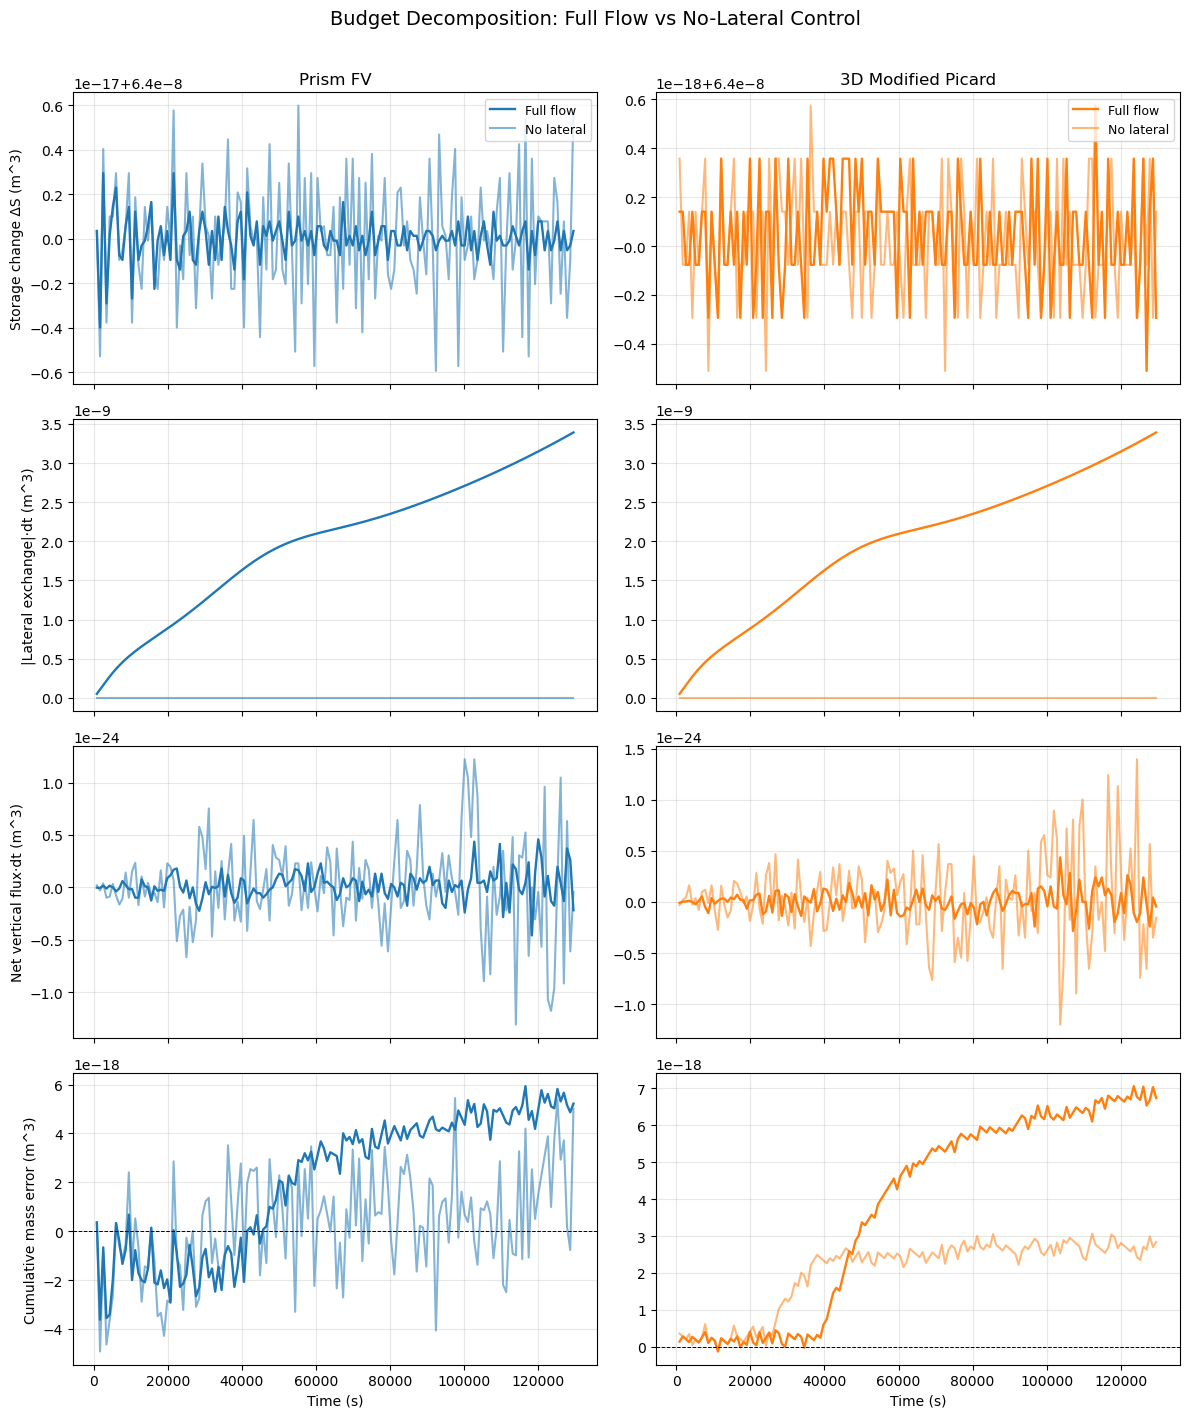

In [35]:
bd_a_vertical_only = run_budget_diagnostics(solver_a_vertical_only, shared_time['dt'], shared_time['steps'])
bd_b_vertical_only = run_budget_diagnostics(solver_b_vertical_only, shared_time['dt'], shared_time['steps'])

grid_panels = [
    (solver_a_label, bd_a, bd_a_vertical_only, 'tab:blue'),
    (solver_b_label, bd_b, bd_b_vertical_only, 'tab:orange'),
]
plot_keys = [
    ('dS', 'Storage change ΔS (m^3)'),
    ('lat_exchange', '|Lateral exchange|·dt (m^3)'),
    ('vert_net_in', 'Net vertical flux·dt (m^3)'),
    ('cum_error', 'Cumulative mass error (m^3)'),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 14), sharex='col')
for col_idx, (grid_title, full_data, no_lat_data, color) in enumerate(grid_panels):
    for row_idx, (key, ylabel) in enumerate(plot_keys):
        ax = axes[row_idx, col_idx]
        ax.plot(full_data['times'], full_data[key], color=color, linewidth=1.7, label='Full flow')
        ax.plot(no_lat_data['times'], no_lat_data[key], color=color, linewidth=1.5, alpha=0.55, label='No lateral')
        if key == 'cum_error':
            ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
        ax.grid(True, alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel(ylabel)
        if row_idx == 0:
            ax.set_title(grid_title)
            ax.legend(loc='upper right', fontsize=9)
        if row_idx == len(plot_keys) - 1:
            ax.set_xlabel('Time (s)')

fig.suptitle('Budget Decomposition: Full Flow vs No-Lateral Control', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## Total Water Content and Hydraulic Head Time Series

This section compares the two solvers at each time step using:
- Total water content (domain water storage, m^3)
- Volume-weighted mean hydraulic head across all cells (m)

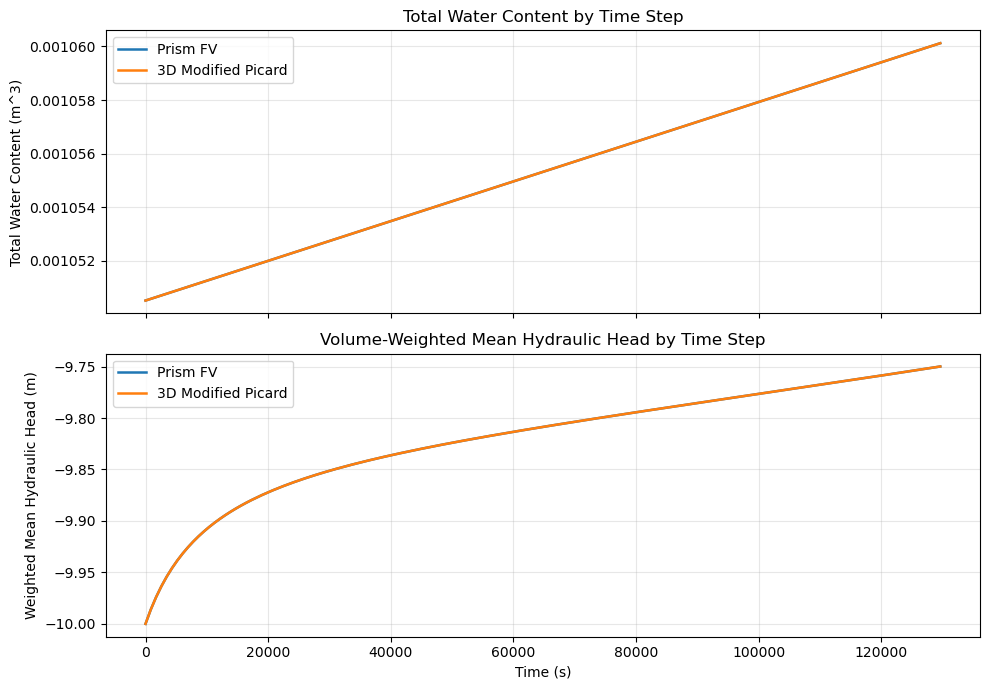

Final total water content (Prism FV): 1.060122e-03 m^3
Final total water content (3D Modified Picard): 1.060122e-03 m^3
Final weighted mean head (Prism FV):  -9.749911e+00 m
Final weighted mean head (3D Modified Picard):  -9.749911e+00 m


In [36]:
def water_content_and_head_series(solver, dt, steps, h0_value=-10.0):
    h = initial_head_state(solver, h0_value=h0_value)
    cell_volumes = get_cell_volumes(solver)

    times = np.zeros(steps + 1)
    storage = np.zeros(steps + 1)
    weighted_mean_head = np.zeros(steps + 1)

    storage[0] = solver.calculate_storage(h)
    weighted_mean_head[0] = np.average(h, weights=cell_volumes)

    for t in range(1, steps + 1):
        h = solve_step_with_shared_forcing(solver, h, dt)
        times[t] = t * dt
        storage[t] = solver.calculate_storage(h)
        weighted_mean_head[t] = np.average(h, weights=cell_volumes)

    return times, storage, weighted_mean_head


t_wc, storage_a, head_a = water_content_and_head_series(solver_a, shared_time['dt'], shared_time['steps'])
_, storage_b, head_b = water_content_and_head_series(solver_b, shared_time['dt'], shared_time['steps'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(t_wc, storage_a, label=solver_a_label, color='tab:blue', linewidth=1.8)
ax1.plot(t_wc, storage_b, label=solver_b_label, color='tab:orange', linewidth=1.8)
ax1.set_ylabel('Total Water Content (m^3)')
ax1.set_title('Total Water Content by Time Step')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(t_wc, head_a, label=solver_a_label, color='tab:blue', linewidth=1.8)
ax2.plot(t_wc, head_b, label=solver_b_label, color='tab:orange', linewidth=1.8)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Weighted Mean Hydraulic Head (m)')
ax2.set_title('Volume-Weighted Mean Hydraulic Head by Time Step')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Final total water content ({solver_a_label}): {storage_a[-1]:.6e} m^3")
print(f"Final total water content ({solver_b_label}): {storage_b[-1]:.6e} m^3")
print(f"Final weighted mean head ({solver_a_label}):  {head_a[-1]:.6e} m")
print(f"Final weighted mean head ({solver_b_label}):  {head_b[-1]:.6e} m")

## Unsaturated-to-Saturated Transition and Lateral-Flow Activation

This section tracks, for both solvers:
- Saturated fraction in each layer over time (cells with h >= 0)
- Lateral exchange by layer and total lateral exchange

Activation time is defined as the first time the total lateral exchange reaches at least 0.1% of its run maximum.

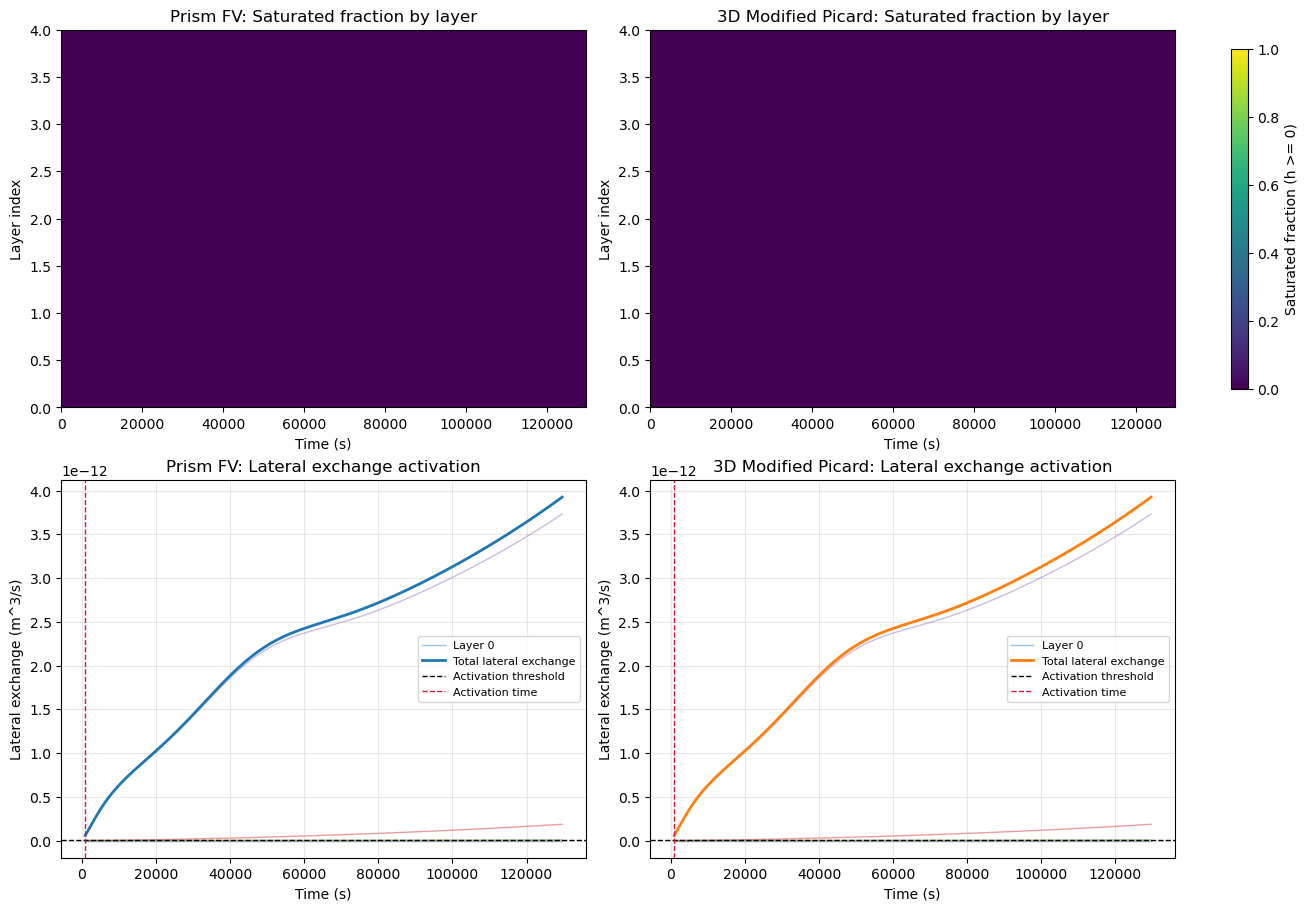

Prism FV lateral activation time: 864.0 s
3D Modified Picard lateral activation time: 864.0 s


In [37]:
def transition_lateral_diagnostics(solver, dt, steps, h0_value=-10.0):
    h = initial_head_state(solver, h0_value=h0_value)
    nL, nP = solver.n_layers, solver.n_prisms

    sat_fraction = np.zeros((nL, steps + 1))
    lat_by_layer = np.zeros((steps, nL))
    lat_total = np.zeros(steps)

    sat_fraction[:, 0] = (h.reshape(nL, nP) >= 0.0).mean(axis=1)

    for t in range(1, steps + 1):
        h = solve_step_with_shared_forcing(solver, h, dt)
        h_layer = h.reshape(nL, nP)
        sat_fraction[:, t] = (h_layer >= 0.0).mean(axis=1)

        for layer in range(nL):
            layer_fluxes = solver.get_lateral_fluxes(h, layer=layer)
            lat_by_layer[t - 1, layer] = sum(abs(q) for q in layer_fluxes.values())

        lat_total[t - 1] = lat_by_layer[t - 1, :].sum()

    times_state = np.arange(steps + 1) * dt
    times_flux = np.arange(1, steps + 1) * dt

    max_lat = np.max(lat_total)
    threshold = 1e-3 * max_lat if max_lat > 0 else 0.0
    active_idx = np.where(lat_total >= threshold)[0]
    t_active = times_flux[active_idx[0]] if len(active_idx) > 0 else np.nan

    return {
        'times_state': times_state,
        'times_flux': times_flux,
        'sat_fraction': sat_fraction,
        'lat_by_layer': lat_by_layer,
        'lat_total': lat_total,
        'lat_activation_threshold': threshold,
        'lat_activation_time': t_active,
    }


diag_a = transition_lateral_diagnostics(solver_a, shared_time['dt'], shared_time['steps'])
diag_b = transition_lateral_diagnostics(solver_b, shared_time['dt'], shared_time['steps'])

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

for ax, diag, title in [
    (axes[0, 0], diag_a, f'{solver_a_label}: Saturated fraction by layer'),
    (axes[0, 1], diag_b, f'{solver_b_label}: Saturated fraction by layer'),
]:
    im = ax.imshow(
        diag['sat_fraction'],
        aspect='auto',
        origin='lower',
        extent=[diag['times_state'][0], diag['times_state'][-1], 0, solver_a.n_layers - 1],
        vmin=0.0,
        vmax=1.0,
        cmap='viridis',
    )
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Layer index')

cbar = fig.colorbar(im, ax=axes[0, :], location='right', shrink=0.9)
cbar.set_label('Saturated fraction (h >= 0)')

for ax, diag, title, color in [
    (axes[1, 0], diag_a, f'{solver_a_label}: Lateral exchange activation', 'tab:blue'),
    (axes[1, 1], diag_b, f'{solver_b_label}: Lateral exchange activation', 'tab:orange'),
]:
    n_layers = diag['lat_by_layer'].shape[1]
    for k in range(n_layers):
        ax.plot(diag['times_flux'], diag['lat_by_layer'][:, k], linewidth=1.0, alpha=0.45, label=f'Layer {k}' if k == 0 else None)

    ax.plot(diag['times_flux'], diag['lat_total'], color=color, linewidth=2.0, label='Total lateral exchange')
    ax.axhline(diag['lat_activation_threshold'], color='black', linestyle='--', linewidth=1.0, label='Activation threshold')
    if np.isfinite(diag['lat_activation_time']):
        ax.axvline(diag['lat_activation_time'], color='crimson', linestyle='--', linewidth=1.0, label='Activation time')

    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Lateral exchange (m^3/s)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.show()

print(f"{solver_a_label} lateral activation time: {diag_a['lat_activation_time']:.1f} s")
print(f"{solver_b_label} lateral activation time: {diag_b['lat_activation_time']:.1f} s")